# #Phase 1: Data Cleaning & Exploratory Data Analysis (EDA)

This notebook focuses on transforming raw forest cover data into a modeling-ready format. Key steps include handling missing values, feature scaling, and conducting correlation analysis to identify significant predictors.

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "forest_cover.csv"
df = pd.read_csv(PATH)


Shape: (30860, 55)

Data types:
 float64    45
int64       9
object      1
Name: count, dtype: int64


,missing_count,missing_pct
Soil_Type20,18516,60.0
Soil_Type29,18207,59.0
Soil_Type36,17898,58.0
Soil_Type31,17898,58.0
Soil_Type37,17590,57.0
Soil_Type19,16664,54.0
Soil_Type30,16355,53.0
Soil_Type26,16047,52.0
Soil_Type33,15738,51.0
Soil_Type12,15738,51.0



Total missing: 444366


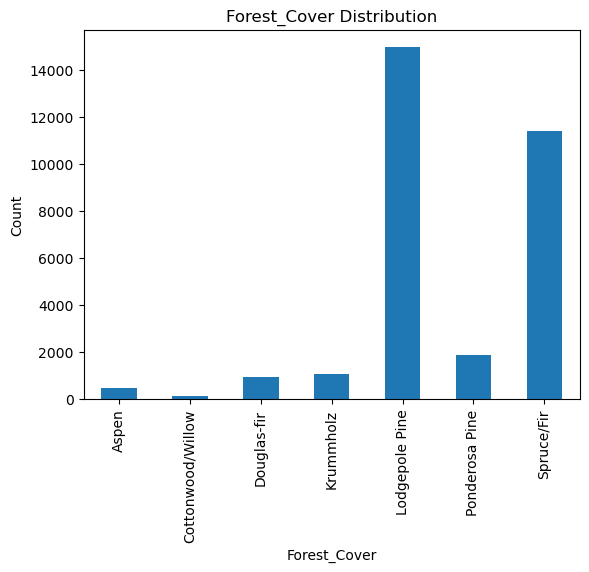

,n_unique
Cache la Poudre,2
Comanche Peak,2
Neota,2
Rawah,2
Soil_Type1,2
Soil_Type10,2
Soil_Type11,2
Soil_Type12,2
Soil_Type13,2
Soil_Type14,2


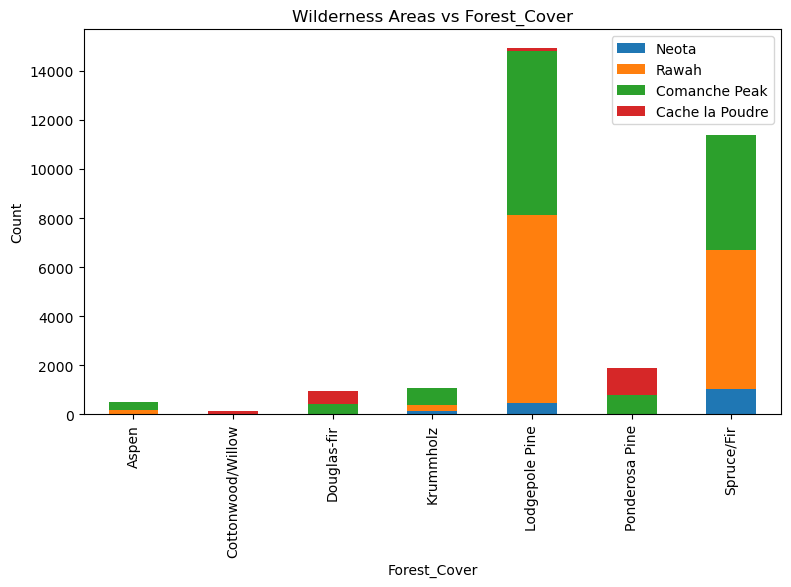

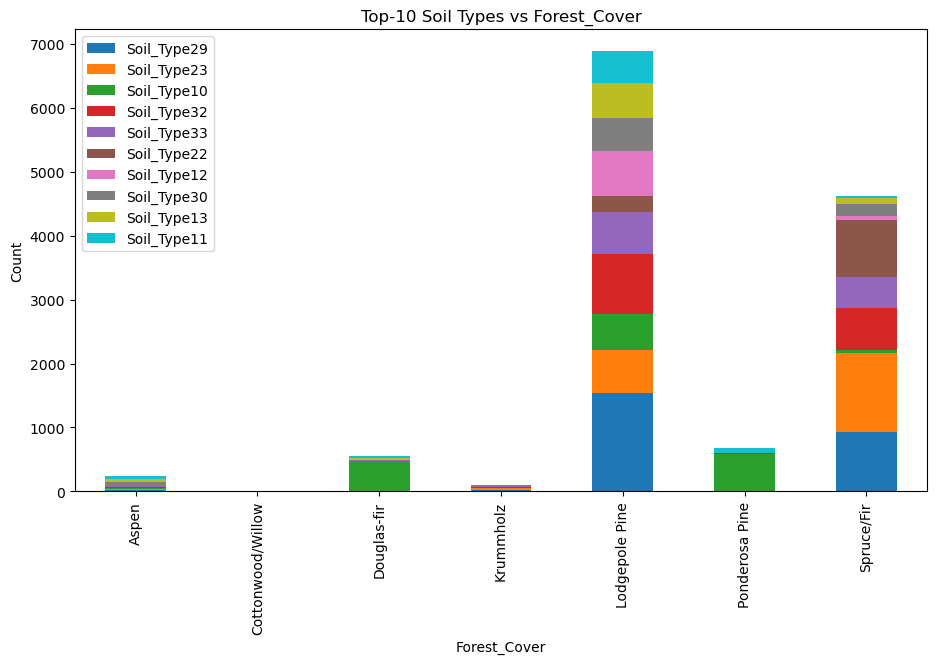

In [105]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes.value_counts())

na_cnt = df.isna().sum()
na_pct = (na_cnt / len(df) * 100).round(2)
missing = pd.DataFrame({"missing_count": na_cnt, "missing_pct": na_pct}).sort_values("missing_count", ascending=False)
display(missing.head(20))  
print("\nTotal missing:", int(na_cnt.sum()))

TARGET = "Forest_Cover"
if TARGET not in df.columns:
    raise KeyError(f"Target column {TARGET} not found. Please check column names via df.columns.")
ax = df[TARGET].value_counts().sort_index().plot(kind="bar", title=f"{TARGET} Distribution")
ax.set_xlabel(TARGET); ax.set_ylabel("Count")
plt.show()


wilderness_names = ["Neota", "Rawah", "Comanche Peak", "Cache la Poudre"]
wilderness_cols = [c for c in df.columns if c in wilderness_names or c.startswith("Wilderness_Area")]
soil_cols = [c for c in df.columns if c.startswith("Soil_Type")]


cat_cols = wilderness_cols + soil_cols
if cat_cols:
    nunique_tbl = df[cat_cols].nunique().sort_index()
    display(pd.DataFrame({"n_unique": nunique_tbl}))


if wilderness_cols:
    (df.groupby(TARGET)[wilderness_cols].sum()
       .plot(kind="bar", stacked=True, figsize=(9,5), title="Wilderness Areas vs Forest_Cover"))
    plt.xlabel(TARGET); plt.ylabel("Count"); plt.show()


if soil_cols:
    top_soils = df[soil_cols].sum().sort_values(ascending=False).head(10).index.tolist()
    (df.groupby(TARGET)[top_soils].sum()
       .plot(kind="bar", stacked=True, figsize=(11,6), title="Top-10 Soil Types vs Forest_Cover"))
    plt.xlabel(TARGET); plt.ylabel("Count"); plt.show()

In [33]:
#step 3 Data Cleaning & Processing

In [35]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# --- Paths ---
IN_PATH  = Path("forest_cover.csv") 
OUT_PATH = Path("desktop/comp5310/ass1/output/forest_cover_clean.csv")          

try:
    df
except NameError:
    df = pd.read_csv(IN_PATH)

#  0) Housekeeping: drop obvious index columns, strip colnames ---
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df.columns = [c.strip() for c in df.columns]



In [37]:
# 1) Identify columns 
TARGET = "Forest_Cover"
if TARGET not in df.columns:
    raise KeyError(f"Target column {TARGET} not found. Check df.columns and adjust TARGET accordingly.")

wilderness_names = ["Neota", "Rawah", "Comanche Peak", "Cache la Poudre"]
wilderness_cols = [c for c in df.columns if c in wilderness_names or c.startswith("Wilderness_Area")]
soil_cols = [c for c in df.columns if c.startswith("Soil_Type")]

# All numeric columns (including one-hots)
num_all = list(df.select_dtypes(include=["number"]).columns)

# Continuous numeric columns (exclude one-hots and the target)
num_cont = [c for c in num_all if c not in set(soil_cols + wilderness_cols + [TARGET])]

obj_cols = list(df.select_dtypes(include=["object"]).columns)

# --- Snapshot before cleaning (for report) ---
orig_shape = df.shape
missing_before = df.isna().sum()
total_missing_before = int(missing_before.sum())
dup_before = int(df.duplicated().sum())
missing_before_report = missing_before.copy()

print(f"[Before] shape={orig_shape}, total_missing={total_missing_before}, duplicates={dup_before}")


[Before] shape=(30833, 55), total_missing=0, duplicates=0


In [39]:
#  2) Imputation 
# 2.1 Continuous numeric -> median
for c in num_cont:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())


# --- Extra safeguard: ensure all NaN are filled ---

for c in df.select_dtypes(include=["number"]).columns:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].median())


for c in df.select_dtypes(include=["object"]).columns:
    if df[c].isna().any():
        mode = df[c].mode(dropna=True)
        df[c] = df[c].fillna(mode.iloc[0] if len(mode) else "Unknown")

# Double check
print("Remaining missing values after safeguard:", df.isna().sum().sum())



Remaining missing values after safeguard: 0


In [41]:
# 2.2 One-hot (soil & wilderness) -> 0
if soil_cols:
    df[soil_cols] = df[soil_cols].fillna(0)
if wilderness_cols:
    df[wilderness_cols] = df[wilderness_cols].fillna(0)

# 2.3 Other object columns -> mode
for c in obj_cols:
    if df[c].isna().any():
        mode = df[c].mode(dropna=True)
        df[c] = df[c].fillna(mode.iloc[0] if len(mode) else "Unknown")


In [43]:
# Step 3.1 deliverable: Missing BEFORE vs AFTER
from pathlib import Path
TAB_DIR = Path("outputs/tables"); TAB_DIR.mkdir(parents=True, exist_ok=True)

missing_after_31 = df.isna().sum()

mv_comp = (
    pd.DataFrame({
        "missing_before": missing_before_report,
        "missing_after":  missing_after_31
    })
    .fillna(0).astype(int)
    .sort_values("missing_before", ascending=False)
)


mv_comp.to_csv(TAB_DIR / "table_3_1_missing_before_after_full.csv")
mv_comp.head(10).to_csv(TAB_DIR / "table_3_1_missing_top10_before_after.csv")

print("[Step 3.1] Total missing:", int(missing_before_report.sum()), "->", int(missing_after_31.sum()))
print("Saved:",
      (TAB_DIR / "table_3_1_missing_before_after_full.csv").resolve(),
      (TAB_DIR / "table_3_1_missing_top10_before_after.csv").resolve())

[Step 3.1] Total missing: 0 -> 0
Saved: /Users/zhangyue/outputs/tables/table_3_1_missing_before_after_full.csv /Users/zhangyue/outputs/tables/table_3_1_missing_top10_before_after.csv


In [45]:
# 3) Simple domain sanity checks 
if "Elevation" in df.columns:
    df.loc[df["Elevation"] < 0, "Elevation"] = 0
if "Slope" in df.columns:
    df.loc[df["Slope"] < 0, "Slope"] = 0
    df.loc[df["Slope"] > 90, "Slope"] = 90
for col in ["Horizontal_Distance_To_Hydrology",
            "Vertical_Distance_To_Hydrology",
            "Horizontal_Distance_To_Roadways",
            "Horizontal_Distance_To_Fire_Points"]:
    if col in df.columns:
        df.loc[df[col] < 0, col] = 0

In [47]:
# 4) (Optional) IQR capping for extreme outliers on continuous numerics
def iqr_cap(series: pd.Series, k: float = 3.0):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return series.clip(lower=lo, upper=hi), float(lo), float(hi)

iqr_summary = {}
for c in num_cont:
    if df[c].notna().sum() > 0 and df[c].nunique(dropna=True) >= 10:
        capped, lo, hi = iqr_cap(df[c], k=3.0)
        capped_count = int((capped != df[c]).sum())
        if capped_count > 0:
            df[c] = capped
            iqr_summary[c] = {"low_cap": lo, "high_cap": hi, "n_capped": capped_count}


In [49]:
#  5) Drop duplicates 
df = df.drop_duplicates()
dup_removed = dup_before


In [51]:
#  6) Target dtype normalization (keep as integer classes if numeric) 
if pd.api.types.is_numeric_dtype(df[TARGET]):
    df[TARGET] = df[TARGET].astype(int)

In [53]:
# 7) After snapshot and save 
missing_after = df.isna().sum()
total_missing_after = int(missing_after.sum())
final_shape = df.shape

In [55]:
# Ensure output folder exists
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_PATH, index=False)


In [57]:
print("\n[After]")
print(f"shape={final_shape}, total_missing={total_missing_after} (was {total_missing_before}), duplicates_removed={dup_removed}")
print(f"Saved cleaned dataset -> {OUT_PATH.resolve()}")



[After]
shape=(30833, 55), total_missing=0 (was 0), duplicates_removed=0
Saved cleaned dataset -> /Users/zhangyue/desktop/comp5310/ass1/output/forest_cover_clean.csv


In [59]:
# Optional
print("\nTop-10 missing columns BEFORE:")
print(missing_before_report.sort_values(ascending=False).head(10))
print("\nTop-10 missing columns AFTER:")
print(missing_after.sort_values(ascending=False).head(10))
if iqr_summary:
    print("\nIQR capping applied to:")
    for c, info in iqr_summary.items():
        print(f"- {c}: capped {info['n_capped']} values to [{info['low_cap']:.3f}, {info['high_cap']:.3f}]")



Top-10 missing columns BEFORE:
Elevation      0
Soil_Type32    0
Soil_Type21    0
Soil_Type22    0
Soil_Type23    0
Soil_Type24    0
Soil_Type25    0
Soil_Type26    0
Soil_Type27    0
Soil_Type28    0
dtype: int64

Top-10 missing columns AFTER:
Elevation      0
Soil_Type32    0
Soil_Type21    0
Soil_Type22    0
Soil_Type23    0
Soil_Type24    0
Soil_Type25    0
Soil_Type26    0
Soil_Type27    0
Soil_Type28    0
dtype: int64

IQR capping applied to:
- Horizontal_Distance_To_Fire_Points: capped 1064 values to [-2444.000, 5984.000]


In [61]:
# Step 4. Exploratory Data Analysis (EDA)

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [65]:
try:
    df
except NameError:
    if Path("forest_cover_clean.csv").exists():
        df = pd.read_csv("forest_cover_clean.csv")
    else:
        df = pd.read_csv("forest_cover.csv")


TARGET = "Forest_Cover"
assert TARGET in df.columns, f"Target column '{TARGET}' not found. Found: {list(df.columns)[:10]} ..."

wilderness_names = ["Neota", "Rawah", "Comanche Peak", "Cache la Poudre"]
wilderness_cols = [c for c in df.columns if c in wilderness_names or c.startswith("Wilderness_Area")]


soil_cols = [c for c in df.columns if c.startswith("Soil_Type")]


one_hot_cols = set(wilderness_cols + soil_cols)
num_cont = [c for c in df.select_dtypes(include=["number"]).columns
            if c not in one_hot_cols and c != TARGET]


FIG_DIR = Path("outputs/figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)

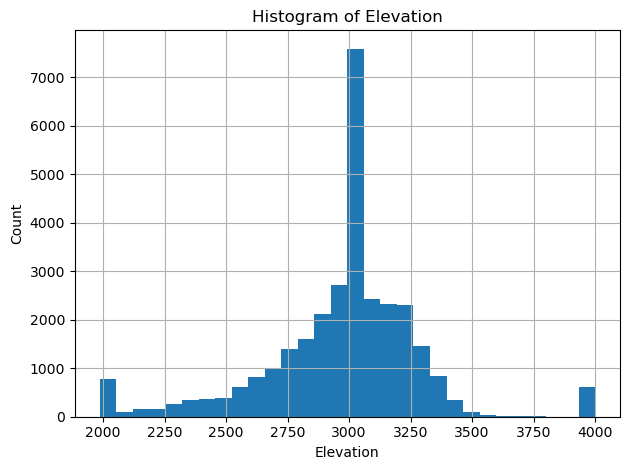

<Figure size 640x480 with 0 Axes>

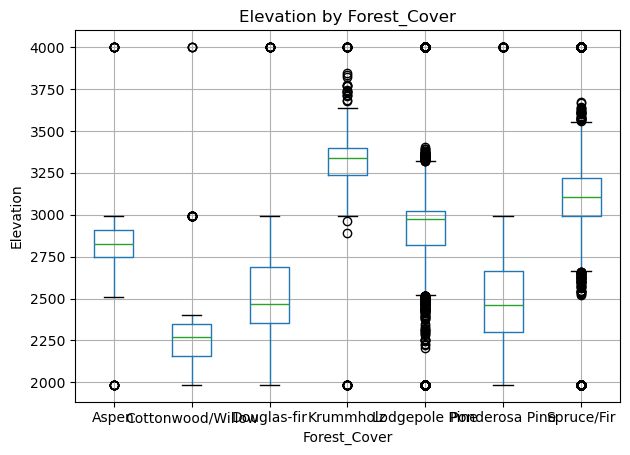

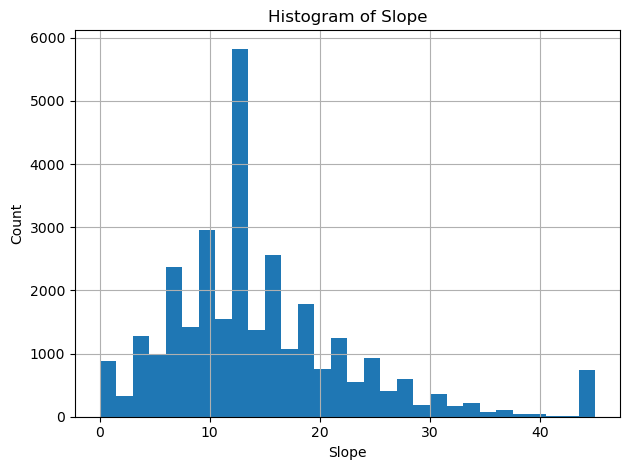

<Figure size 640x480 with 0 Axes>

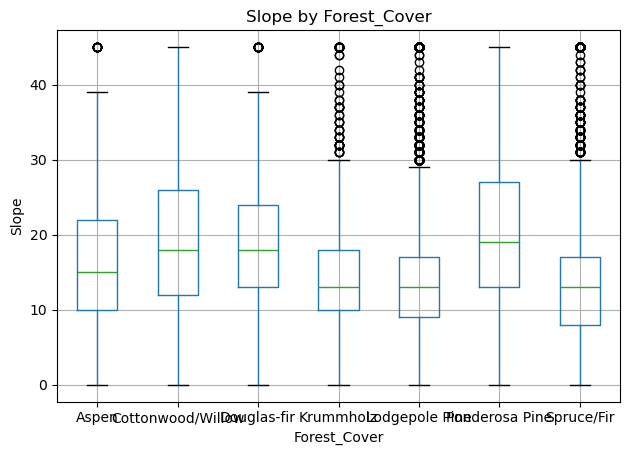

In [177]:
for c in [col for col in ["Elevation", "Slope"] if col in df.columns]:
    
    plt.figure()
    df[c].hist(bins=30)
    plt.title(f"Histogram of {c}")4
    plt.xlabel(c); plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"hist_{c}.png", dpi=150)
    plt.show()

   
    plt.figure()
    df.boxplot(column=c, by=TARGET)
    plt.title(f"{c} by {TARGET}")
    plt.suptitle("")
    plt.xlabel(TARGET); plt.ylabel(c)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"box_{c}_by_{TARGET}.png", dpi=150)
    plt.show()

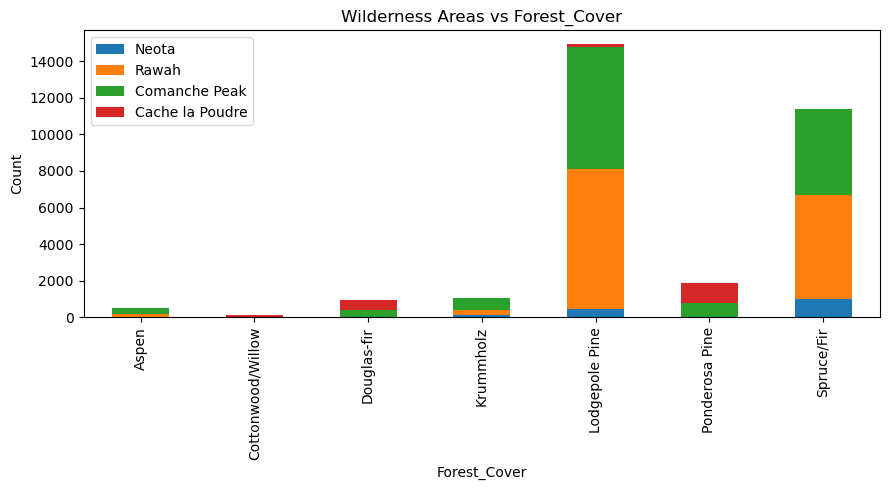

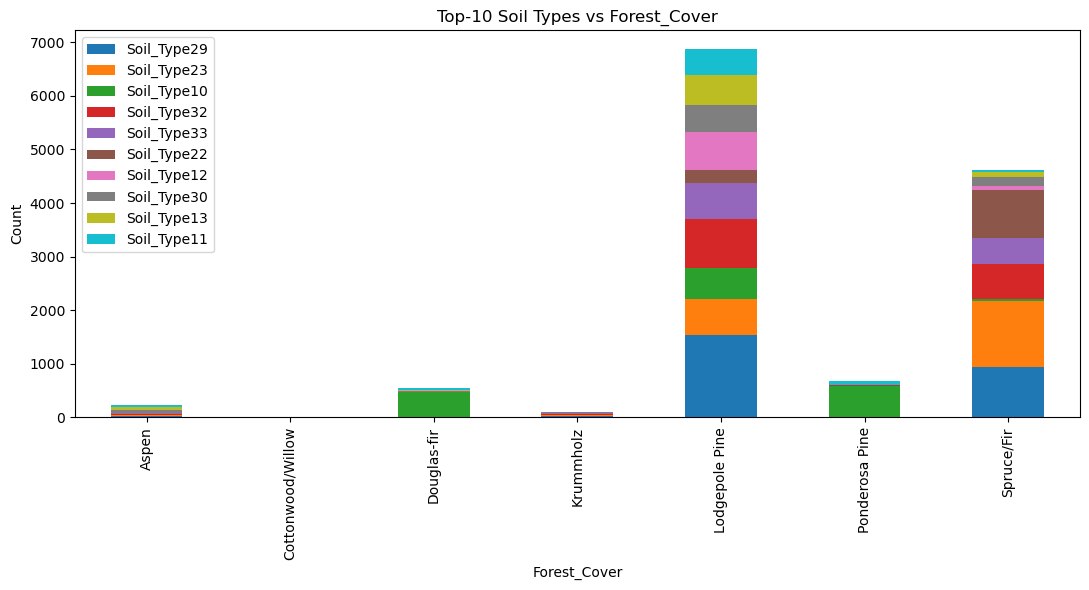

In [99]:
#  4.3 Categorical: Soil_Type Top-10 stacked bar 
if soil_cols:
    top_soils = df[soil_cols].sum().sort_values(ascending=False).head(10).index.tolist()
    plt.figure(figsize=(11,6))
    (df.groupby(TARGET)[top_soils].sum()
       .plot(kind="bar", stacked=True, ax=plt.gca(), title=f"Top-10 Soil Types vs {TARGET}"))
    plt.xlabel(TARGET); plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"stack_top10_soil_vs_{TARGET}.png", dpi=150)
    plt.show()

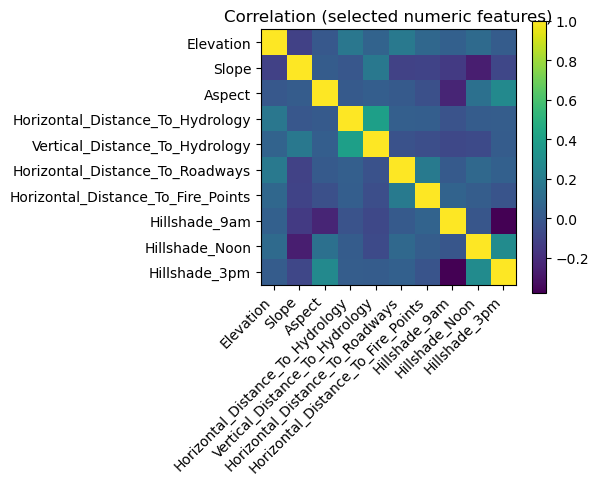

EDA figures saved to: /Users/zhangyue/outputs/figs


In [101]:
#  4.4 Correlation heatmap 
candidates = [col for col in ["Elevation","Slope",
                              "Aspect",
                              "Horizontal_Distance_To_Hydrology",
                              "Vertical_Distance_To_Hydrology",
                              "Horizontal_Distance_To_Roadways",
                              "Horizontal_Distance_To_Fire_Points",
                              "Hillshade_9am","Hillshade_Noon","Hillshade_3pm"]
              if col in df.columns]
if candidates:
    corr = df[candidates].corr()
    plt.figure(figsize=(6,5))
    plt.imshow(corr, interpolation="nearest")
    plt.title("Correlation (selected numeric features)")
    plt.xticks(range(len(candidates)), candidates, rotation=45, ha="right")
    plt.yticks(range(len(candidates)), candidates)
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "corr_selected_numeric.png", dpi=150)
    plt.show()

print("EDA figures saved to:", FIG_DIR.resolve())